In [3]:
%load_ext autoreload

In [4]:
%autoreload 2
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import plotly.express as px

from darpinstances.results import load_aggregate_stats_in_dir
from darpinstances.instance_generation.convert_formats import RESOURCE_PATH
from darpinstances.instance_generation.demand_to_database import load_table_from_db, load_data_from_csv, load_demand_to_db

/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"
/home/dominika/Desktop/deathOFbachelor/Ridesharing_DARP_instances/python/darpinstances/instance.py:23: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


# path setup

In [5]:
run_id = "1-run-23-3"

In [6]:
PATH = Path.cwd()
current_path = PATH
INSTANCE_PATH = PATH.parents[2] / "Instances"
RESULTS_PATH = PATH.parents[2] / "final-results" / run_id / "Results"

In [7]:
PATH = PATH.parents[2]
os.chdir(PATH)
IMG_PATH = PATH / "Ridesharing_DARP_instances/figures/bc-dominika"

In [8]:
Path.cwd()

PosixPath('/home/dominika/Desktop/deathOFbachelor')

In [9]:
plt.rc('font', size=20)

In [11]:
PATH

PosixPath('/home/dominika/Desktop/deathOFbachelor')

# Solutions

In [10]:
# areas = ['Porto']
# areas = ['Sydney']
areas = ['Porto', 'Sydney', 'DC', 'Manhattan', 'Chicago', 'NYC']
area = areas[0]

## prepare occupancy dataframe

In [11]:
from darpinstances.results import load_occupancies_in_dir
oc_df = pd.DataFrame()
for area in areas:
    res_in_area = load_occupancies_in_dir(RESULTS_PATH / area)
    if res_in_area is None:
        continue
    res_in_area['area'] = area
    oc_df = pd.concat([oc_df, res_in_area], ignore_index=True)
    # os.chdir(PATH)

12:41:31 [INFO] Loading occupancy stats in /home/dominika/Desktop/deathOFbachelor/final-results/1-run-23-3/Results/Porto
12:41:31 [INFO] Loading json file from: /home/dominika/Desktop/deathOFbachelor/final-results/1-run-23-3/Results/Porto/start_18-00/duration_05_min/max_delay_10_min/capacity_6/vga_chaining/config.yaml-solution.json
12:41:31 [INFO] Loading json file from: /home/dominika/Desktop/deathOFbachelor/final-results/1-run-23-3/Results/Porto/start_18-00/duration_05_min/max_delay_10_min/capacity_6/vga_chaining/config.yaml-performance.json
12:41:31 [INFO] Loading experiment config from /home/dominika/Desktop/deathOFbachelor/final-results/1-run-23-3/Results/Porto/start_18-00/duration_05_min/max_delay_10_min/capacity_6/vga_chaining/config.yaml
12:41:31 [INFO] Loading instance config from /home/dominika/Desktop/deathOFbachelor/Instances/Porto/instances/start_18-00/duration_05_min/max_delay_10_min/capacity_6/config.yaml
12:41:31 [INFO] Loading json file from: /home/dominika/Desktop/dea

12:41:31 [INFO] Loading json file from: /home/dominika/Desktop/deathOFbachelor/final-results/1-run-23-3/Results/Porto/start_18-00/duration_05_min/max_delay_10_min/capacity_10/halns/config.yaml-solution.json
12:41:31 [INFO] Loading json file from: /home/dominika/Desktop/deathOFbachelor/final-results/1-run-23-3/Results/Porto/start_18-00/duration_05_min/max_delay_10_min/capacity_10/halns/config.yaml-performance.json
12:41:31 [INFO] Loading experiment config from /home/dominika/Desktop/deathOFbachelor/final-results/1-run-23-3/Results/Porto/start_18-00/duration_05_min/max_delay_10_min/capacity_10/halns/config.yaml
12:41:31 [INFO] Loading instance config from /home/dominika/Desktop/deathOFbachelor/Instances/Porto/instances/start_18-00/duration_05_min/max_delay_10_min/capacity_10/config.yaml
12:41:31 [INFO] Loading json file from: /home/dominika/Desktop/deathOFbachelor/final-results/1-run-23-3/Results/Porto/start_18-00/duration_05_min/max_delay_10_min/capacity_10/ih/config.yaml-solution.json


In [12]:
oc_df['cost_per_request'] = oc_df['cost_minutes'] * 60 / oc_df['req_count']
oc_df['area_short'] = oc_df['area'].map({
    'Porto': 'PT',
    'Sydney': 'SY',
    'DC': 'DC',
    'Manhattan': 'MH',
    'Chicago': 'CH',
    'NYC': 'NY'
})
area_order = {
    'Porto': 0,
    'Sydney': 1,
    'DC': 2,
    'Manhattan': 3,
    'Chicago': 4,
    'NYC': 5
}
oc_df['area_order'] = oc_df['area'].map(area_order)
oc_df.sort_values(by=['area_order', 'duration_minutes', 'max_delay', 'method'], inplace=True)

In [222]:
oc_df

,cost_minutes,total_time,dropped_requests,solver_stats,avg_delay,plan_count,req_count,avg_occupancy,used_connections,total_driving_duration,...,max_delay,start_time,end_time,duration_minutes,occupancy,vehicle_hours,area,cost_per_request,area_short,area_order
275,120,4.724,0,Solver has no performance stats,296.894737,10,19,0.763296,-1,7220,...,180,2013-07-01 18:00:00,2013-07-01 18:05:00,5,0,0.798056,Porto,378.947368,PT,0
276,120,4.724,0,Solver has no performance stats,296.894737,10,19,0.763296,-1,7220,...,180,2013-07-01 18:00:00,2013-07-01 18:05:00,5,1,0.948056,Porto,378.947368,PT,0
277,120,4.724,0,Solver has no performance stats,296.894737,10,19,0.763296,-1,7220,...,180,2013-07-01 18:00:00,2013-07-01 18:05:00,5,2,0.195556,Porto,378.947368,PT,0
278,120,4.724,0,Solver has no performance stats,296.894737,10,19,0.763296,-1,7220,...,180,2013-07-01 18:00:00,2013-07-01 18:05:00,5,3,0.063889,Porto,378.947368,PT,0
279,120,4.724,0,Solver has no performance stats,296.894737,10,19,0.763296,-1,7220,...,180,2013-07-01 18:00:00,2013-07-01 18:05:00,5,4,0.000000,Porto,378.947368,PT,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2580,272099,131.899,0,Solver has no performance stats,882.262370,2392,36944,1.981690,-1,16325940,...,900,2014-01-01 18:00:00,2014-01-01 20:00:00,120,6,0.000000,Sydney,441.910459,SY,1
2581,272099,131.899,0,Solver has no performance stats,882.262370,2392,36944,1.981690,-1,16325940,...,900,2014-01-01 18:00:00,2014-01-01 20:00:00,120,7,0.000000,Sydney,441.910459,SY,1
2582,272099,131.899,0,Solver has no performance stats,882.262370,2392,36944,1.981690,-1,16325940,...,900,2014-01-01 18:00:00,2014-01-01 20:00:00,120,8,0.000000,Sydney,441.910459,SY,1
2583,272099,131.899,0,Solver has no performance stats,882.262370,2392,36944,1.981690,-1,16325940,...,900,2014-01-01 18:00:00,2014-01-01 20:00:00,120,9,0.000000,Sydney,441.910459,SY,1


## prepare basic dataframe

In [13]:
df = pd.DataFrame()
for area in areas:
    res_in_area = load_aggregate_stats_in_dir(RESULTS_PATH / area)
    if res_in_area is None:
        continue
    res_in_area['area'] = area
    df = pd.concat([df, res_in_area], ignore_index=True)
    # os.chdir(PATH)
df

12:43:13 [INFO] Loading aggregate stats in /home/dominika/Desktop/deathOFbachelor/final-results/1-run-23-3/Results/Porto
12:43:13 [INFO] Loading json file from: /home/dominika/Desktop/deathOFbachelor/final-results/1-run-23-3/Results/Porto/start_18-00/duration_05_min/max_delay_10_min/capacity_6/vga_chaining/config.yaml-solution.json
12:43:13 [INFO] Loading json file from: /home/dominika/Desktop/deathOFbachelor/final-results/1-run-23-3/Results/Porto/start_18-00/duration_05_min/max_delay_10_min/capacity_6/vga_chaining/config.yaml-performance.json
12:43:13 [INFO] Loading experiment config from /home/dominika/Desktop/deathOFbachelor/final-results/1-run-23-3/Results/Porto/start_18-00/duration_05_min/max_delay_10_min/capacity_6/vga_chaining/config.yaml
12:43:13 [INFO] Loading instance config from /home/dominika/Desktop/deathOFbachelor/Instances/Porto/instances/start_18-00/duration_05_min/max_delay_10_min/capacity_6/config.yaml
12:43:13 [INFO] Loading json file from: /home/dominika/Desktop/dea

12:43:13 [INFO] Loading json file from: /home/dominika/Desktop/deathOFbachelor/final-results/1-run-23-3/Results/Porto/start_18-00/duration_05_min/max_delay_10_min/capacity_10/vga_chaining/config.yaml-solution.json
12:43:13 [INFO] Loading json file from: /home/dominika/Desktop/deathOFbachelor/final-results/1-run-23-3/Results/Porto/start_18-00/duration_05_min/max_delay_10_min/capacity_10/vga_chaining/config.yaml-performance.json
12:43:13 [INFO] Loading experiment config from /home/dominika/Desktop/deathOFbachelor/final-results/1-run-23-3/Results/Porto/start_18-00/duration_05_min/max_delay_10_min/capacity_10/vga_chaining/config.yaml
12:43:13 [INFO] Loading instance config from /home/dominika/Desktop/deathOFbachelor/Instances/Porto/instances/start_18-00/duration_05_min/max_delay_10_min/capacity_10/config.yaml
12:43:13 [INFO] Loading json file from: /home/dominika/Desktop/deathOFbachelor/final-results/1-run-23-3/Results/Porto/start_18-00/duration_05_min/max_delay_10_min/capacity_10/halns/co

,method,cost_minutes,total_time,avg_delay,dropped_requests,req_count,plan_count,total_driving_duration,total_waiting_duration,avg_waiting_duration,avg_occupancy,tts_cost,tts_cost_per_plan,used_connections,duration_minutes,max_delay,start_time,end_time,trip_durations,area
0,vga_chaining,85,0.234,378.894737,0,19,6,5110,130,21.666667,1.382387,800,133.333333,18,5,600,2013-07-01 18:00:00,2013-07-01 18:05:00,"[288, 458, 99, 842, 187, 235, 127, 129, 510, 3...",Porto
1,halns,92,14.980,372.578947,0,19,6,5492,15,2.500000,1.286235,1182,197.000000,-1,5,600,2013-07-01 18:00:00,2013-07-01 18:05:00,"[288, 458, 129, 418, 378, 823, 340, 340, 246, ...",Porto
2,ih,93,0.000,440.736842,0,19,6,5580,0,0.000000,1.500717,877,146.166667,-1,5,600,2013-07-01 18:00:00,2013-07-01 18:05:00,"[99, 527, 724, 133, 189, 521, 1135, 102, 340, ...",Porto
3,vga,85,1.949,378.894737,0,19,6,5110,130,21.666667,1.382387,800,133.333333,-1,5,600,2013-07-01 18:00:00,2013-07-01 18:05:00,"[99, 842, 288, 458, 122, 102, 391, 1005, 129, ...",Porto
4,vga_chaining,85,0.241,378.894737,0,19,6,5110,130,21.666667,1.382387,800,133.333333,18,5,600,2013-07-01 18:00:00,2013-07-01 18:05:00,"[288, 458, 99, 842, 187, 235, 127, 129, 510, 3...",Porto
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
236,ih,419595,133.323,725.425022,0,36944,2671,25175700,1737016,650.324223,1.057041,983710,368.292774,-1,120,180,2014-01-01 18:00:00,2014-01-01 20:00:00,"[412, 421, 615, 390, 751, 1273, 52, 380, 127, ...",Sydney
237,ih,419595,133.832,725.425022,0,36944,2671,25175700,1737016,650.324223,1.057041,983710,368.292774,-1,120,180,2014-01-01 18:00:00,2014-01-01 20:00:00,"[412, 421, 615, 390, 751, 1273, 52, 380, 127, ...",Sydney
238,ih,365656,141.444,757.510963,0,36944,2596,21939352,2160274,832.154854,1.266095,514917,198.350154,-1,120,300,2014-01-01 18:00:00,2014-01-01 20:00:00,"[319, 547, 98, 931, 863, 336, 70, 1595, 3205, ...",Sydney
239,ih,365656,139.289,757.510963,0,36944,2596,21939352,2160274,832.154854,1.266095,514917,198.350154,-1,120,300,2014-01-01 18:00:00,2014-01-01 20:00:00,"[319, 547, 98, 931, 863, 336, 70, 1595, 3205, ...",Sydney


In [14]:
df['cost_per_request'] = df['cost_minutes'] * 60 / df['req_count']
df['area_short'] = df['area'].map({
    'Porto': 'PT',
    'Sydney': 'SY',
    'DC': 'DC',
    'Manhattan': 'MH',
    'Chicago': 'CH',
    'NYC': 'NY'
})
area_order = {
    'Porto': 0,
    'Sydney': 1,
    'DC': 2,
    'Manhattan': 3,
    'Chicago': 4,
    'NYC': 5
}
df['area_order'] = df['area'].map(area_order)
df.sort_values(by=['area_order', 'duration_minutes', 'max_delay', 'method'], inplace=True)

In [39]:
df

,method,cost_minutes,total_time,avg_delay,dropped_requests,req_count,plan_count,total_driving_duration,total_waiting_duration,avg_waiting_duration,...,used_connections,duration_minutes,max_delay,start_time,end_time,trip_durations,area,cost_per_request,area_short,area_order
25,halns,120,4.724,296.894737,0,19,10,7220,130,13.000000,...,-1,5,180,2013-07-01 18:00:00,2013-07-01 18:05:00,"[288, 458, 189, 129, 127, 572, 247, 276, 276, ...",Porto,378.947368,PT,0
29,halns,120,4.729,296.894737,0,19,10,7220,130,13.000000,...,-1,5,180,2013-07-01 18:00:00,2013-07-01 18:05:00,"[288, 458, 189, 129, 127, 572, 247, 276, 276, ...",Porto,378.947368,PT,0
33,halns,120,4.666,296.894737,0,19,10,7220,130,13.000000,...,-1,5,180,2013-07-01 18:00:00,2013-07-01 18:05:00,"[288, 458, 189, 129, 127, 572, 247, 276, 276, ...",Porto,378.947368,PT,0
26,ih,142,0.000,295.631579,0,19,11,8502,4,0.363636,...,-1,5,180,2013-07-01 18:00:00,2013-07-01 18:05:00,"[653, 129, 127, 572, 273, 470, 122, 746, 99, 1...",Porto,448.421053,PT,0
30,ih,142,0.000,295.631579,0,19,11,8502,4,0.363636,...,-1,5,180,2013-07-01 18:00:00,2013-07-01 18:05:00,"[653, 129, 127, 572, 273, 470, 122, 746, 99, 1...",Porto,448.421053,PT,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
230,ih,301806,141.731,826.653665,0,36944,2505,18108389,2059536,822.170060,...,-1,120,600,2014-01-01 18:00:00,2014-01-01 20:00:00,"[163, 713, 504, 436, 615, 390, 778, 880, 311, ...",Sydney,490.156994,SY,1
231,ih,301806,139.518,826.653665,0,36944,2505,18108389,2059536,822.170060,...,-1,120,600,2014-01-01 18:00:00,2014-01-01 20:00:00,"[163, 713, 504, 436, 615, 390, 778, 880, 311, ...",Sydney,490.156994,SY,1
232,ih,272099,133.612,882.262370,0,36944,2392,16325940,1711771,715.623328,...,-1,120,900,2014-01-01 18:00:00,2014-01-01 20:00:00,"[274, 1008, 688, 227, 1072, 201, 363, 86, 974,...",Sydney,441.910459,SY,1
233,ih,272099,133.537,882.262370,0,36944,2392,16325940,1711771,715.623328,...,-1,120,900,2014-01-01 18:00:00,2014-01-01 20:00:00,"[274, 1008, 688, 227, 1072, 201, 363, 86, 974,...",Sydney,441.910459,SY,1


## average cost per request (old)

In [ ]:
dfih = df[df['method'] == 'ih']
fig = px.bar(
    dfih,
    x = 'area_short',
    y = 'cost_per_request',
    barmode='group',
    title = 'Average Cost per Request',
    facet_col='duration_minutes',
    facet_row='max_delay'
)

# shared axes titles
fig.for_each_yaxis(lambda y: y.update(title = ''))
fig.add_annotation(x=-0.06, y=0.5, text="travel time per request [s]", textangle=-90, xref="paper", yref="paper", showarrow=False)
fig.for_each_xaxis(lambda y: y.update(title = ''))

# faceting annotations
fig.add_annotation(x=0.5, y=1.15, text="instance length [min]",  xref="paper", yref="paper", showarrow=False)
fig.add_annotation(x=1.02, y=0.5, text="maximum delay [s]",  xref="paper", yref="paper", showarrow=False, textangle=90)

# faceting label editing
fig.for_each_annotation(lambda a: a.update(text=a.text.split("=")[-1]))

fig.show()

In [53]:
dfih['cost_per_request'].describe()

count     96.000000
mean     458.081589
std      128.734668
min      268.387097
25%      356.179966
50%      445.165756
75%      563.238886
max      713.136531
Name: cost_per_request, dtype: float64

# Basic info

In [55]:
df['trip_durations'] = df['trip_durations'].apply(lambda x: np.array(x))
all_durations = np.concatenate(df['trip_durations'].values)

all_durations_minutes = all_durations / 60

sorted_durations = np.sort(all_durations_minutes)

In [56]:
df['trip_durations_mins'] = df['trip_durations'].apply(lambda x: (np.array(x) / 60).round())
all_durations_mins = np.concatenate(df['trip_durations_mins'].values)
trip_count = len(all_durations_mins)

In [57]:
bin_edges = list(range(0, 31, 5)) + [float('inf')]

In [58]:
counts, edges = np.histogram(all_durations_mins, bins=bin_edges)
percentages = counts / len(all_durations_mins) * 100

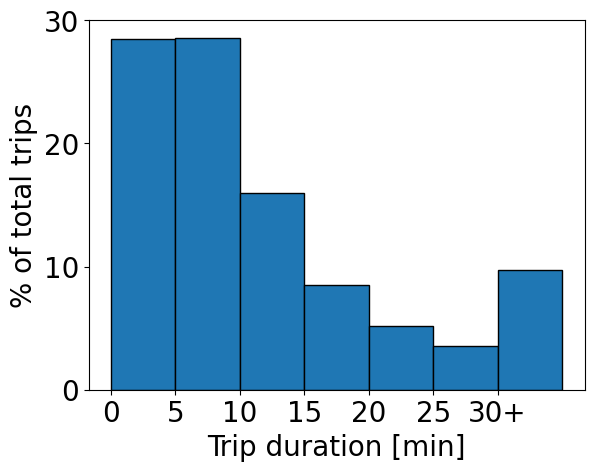

In [59]:
plt.figure()
# plt.figure(figsize=(5, 3))
plt.bar(range(len(counts)), percentages, align='edge', width=1, edgecolor='black')
plt.xlabel("Trip duration [min]")
plt.ylabel("% of total trips")
# plt.title("Trip Duration Distribution")

tick_positions = np.arange(len(edges) - 1)  # One tick for each bin edge
tick_labels = [f"{int(edges[i])}" for i in range(len(edges) - 2)] + ["30+"]
plt.xticks(tick_positions, tick_labels)

plt.savefig(f'{area}_trip_duration_histogram.png', bbox_inches='tight')

plt.show()

In [60]:
df['total_driving_duration_minutes'] = df['total_driving_duration'] / 60
df['driving_duration_mins_per_vehicle'] = df['total_driving_duration_minutes']/df['plan_count']


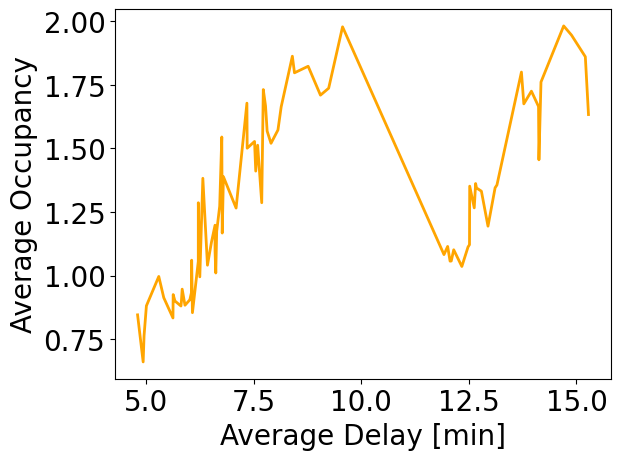

In [61]:
# Create a scatter plot
# plt.figure(figsize=(10, 6))

x_values = (df['avg_delay']/60).values
y1_values = df['avg_occupancy'].values

# Sort data by avg_delay to align the plots properly
sorted_indices = x_values.argsort()
x_values = x_values[sorted_indices]
y1_values = y1_values[sorted_indices]

plt.figure()
plt.plot(x_values, y1_values, color='orange', linewidth=2)
plt.xlabel('Average Delay [min]')
plt.ylabel('Average Occupancy')
# plt.grid(True)
plt.savefig(f'{area}_delay_occupancy.png', bbox_inches='tight')
plt.show()

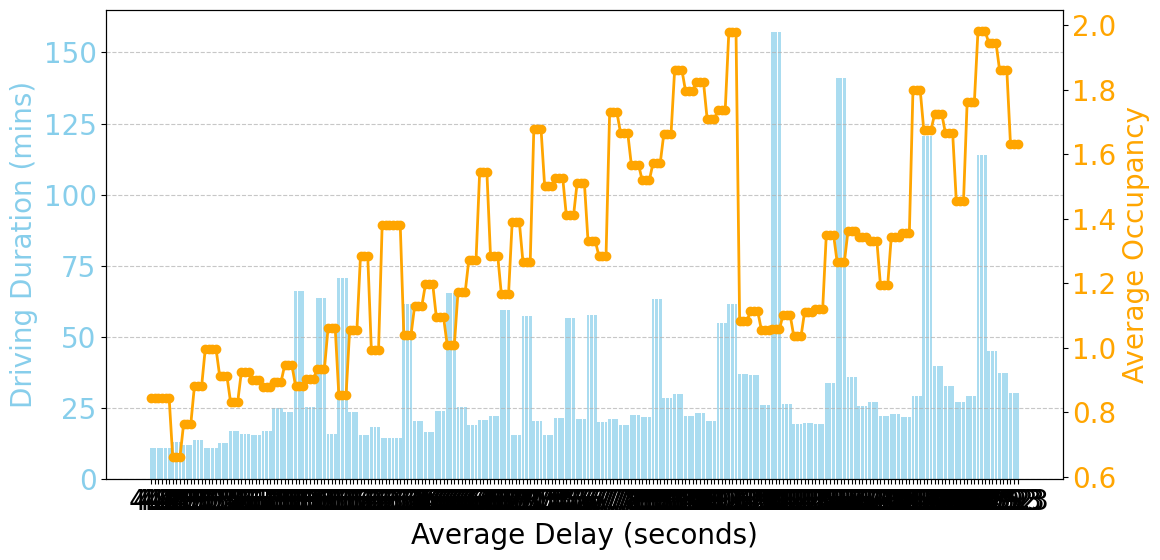

In [62]:
import matplotlib.pyplot as plt

# Prepare data
x_values = (df['avg_delay']/60).values
y1_values = df['avg_occupancy'].values
y2_values = df['driving_duration_mins_per_vehicle'].values

# Sort data by avg_delay to align the plots properly
sorted_indices = x_values.argsort()
x_values = x_values[sorted_indices]
y1_values = y1_values[sorted_indices]
y2_values = y2_values[sorted_indices]

# Create the figure and axis
fig, ax1 = plt.subplots(figsize=(12, 6))

bar_positions = np.arange(len(x_values))

# Plot bar graph for driving duration
ax1.bar(bar_positions, y2_values, color='skyblue', alpha=0.7, label='Driving Duration (mins)', width=0.8)
ax1.set_ylabel('Driving Duration (mins)', color='skyblue')
ax1.set_xlabel('Average Delay (seconds)')
ax1.tick_params(axis='y', labelcolor='skyblue')

x_ticks = np.round(x_values, 1)  # Round avg_delay to 1 decimal place for clarity
ax1.set_xticks(bar_positions)
ax1.set_xticklabels([f"{tick:.1f}" for tick in x_ticks])

# Create a second y-axis for the line plot
ax2 = ax1.twinx()
ax2.plot(bar_positions, y1_values, color='orange', marker='o', linewidth=2, label='Average Occupancy')
ax2.set_ylabel('Average Occupancy', color='orange')
ax2.tick_params(axis='y', labelcolor='orange')

# Title and grid
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# Add legends
# fig.legend(loc='upper left', bbox_to_anchor=(0, 1), bbox_transform=ax1.transAxes)

# Show the plot
# plt.savefig(f'{area}_trip_dur_occupancy_delay.png', bbox_inches='tight')
plt.tight_layout()
plt.show()


In [64]:
oc_df

,cost_minutes,total_time,dropped_requests,solver_stats,avg_delay,plan_count,req_count,avg_occupancy,used_connections,total_driving_duration,...,tts_cost,tts_cost_per_plan,trip_durations,method,max_delay,start_time,end_time,duration_minutes,occupancy,vehicle_hours
0,85,0.234,0,"{'VGA_time': 207, 'chaining_time': 27, 'group_...",378.894737,6,19,1.382387,18,5110,...,800,133.333333,"[288, 458, 99, 842, 187, 235, 127, 129, 510, 3...",vga_chaining,600,2013-07-01 18:00:00,2013-07-01 18:05:00,5,0,0.222222
1,85,0.234,0,"{'VGA_time': 207, 'chaining_time': 27, 'group_...",378.894737,6,19,1.382387,18,5110,...,800,133.333333,"[288, 458, 99, 842, 187, 235, 127, 129, 510, 3...",vga_chaining,600,2013-07-01 18:00:00,2013-07-01 18:05:00,5,1,0.634722
2,85,0.234,0,"{'VGA_time': 207, 'chaining_time': 27, 'group_...",378.894737,6,19,1.382387,18,5110,...,800,133.333333,"[288, 458, 99, 842, 187, 235, 127, 129, 510, 3...",vga_chaining,600,2013-07-01 18:00:00,2013-07-01 18:05:00,5,2,0.382500
3,85,0.234,0,"{'VGA_time': 207, 'chaining_time': 27, 'group_...",378.894737,6,19,1.382387,18,5110,...,800,133.333333,"[288, 458, 99, 842, 187, 235, 127, 129, 510, 3...",vga_chaining,600,2013-07-01 18:00:00,2013-07-01 18:05:00,5,3,0.157500
4,85,0.234,0,"{'VGA_time': 207, 'chaining_time': 27, 'group_...",378.894737,6,19,1.382387,18,5110,...,800,133.333333,"[288, 458, 99, 842, 187, 235, 127, 129, 510, 3...",vga_chaining,600,2013-07-01 18:00:00,2013-07-01 18:05:00,5,4,0.022500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1788,2283,0.013,0,Solver has no performance stats,396.943343,35,353,1.009930,-1,136958,...,4963,141.800000,"[267, 64, 442, 468, 485, 64, 418, 418, 500, 60...",ih,300,2013-07-01 18:00:00,2013-07-01 20:00:00,120,6,0.000000
1789,2283,0.013,0,Solver has no performance stats,396.943343,35,353,1.009930,-1,136958,...,4963,141.800000,"[267, 64, 442, 468, 485, 64, 418, 418, 500, 60...",ih,300,2013-07-01 18:00:00,2013-07-01 20:00:00,120,7,0.000000
1790,2283,0.013,0,Solver has no performance stats,396.943343,35,353,1.009930,-1,136958,...,4963,141.800000,"[267, 64, 442, 468, 485, 64, 418, 418, 500, 60...",ih,300,2013-07-01 18:00:00,2013-07-01 20:00:00,120,8,0.000000
1791,2283,0.013,0,Solver has no performance stats,396.943343,35,353,1.009930,-1,136958,...,4963,141.800000,"[267, 64, 442, 468, 485, 64, 418, 418, 500, 60...",ih,300,2013-07-01 18:00:00,2013-07-01 20:00:00,120,9,0.000000


In [195]:
driving_hours = (oc_df['total_driving_duration']/60/60).round(2)
vehicle_hours = oc_df['vehicle_hours']
occupancies = oc_df['occupancy']
vehicle_hours_percentage = (vehicle_hours / driving_hours) * 100
oc_df['vehicle_hours_percentage'] = vehicle_hours_percentage
oc_df['driving_hours'] = driving_hours

In [196]:
grouped = oc_df.pivot(index='driving_hours', columns='occupancy', values='vehicle_hours_percentage')

ValueError: Index contains duplicate entries, cannot reshape

NameError: name 'grouped' is not defined

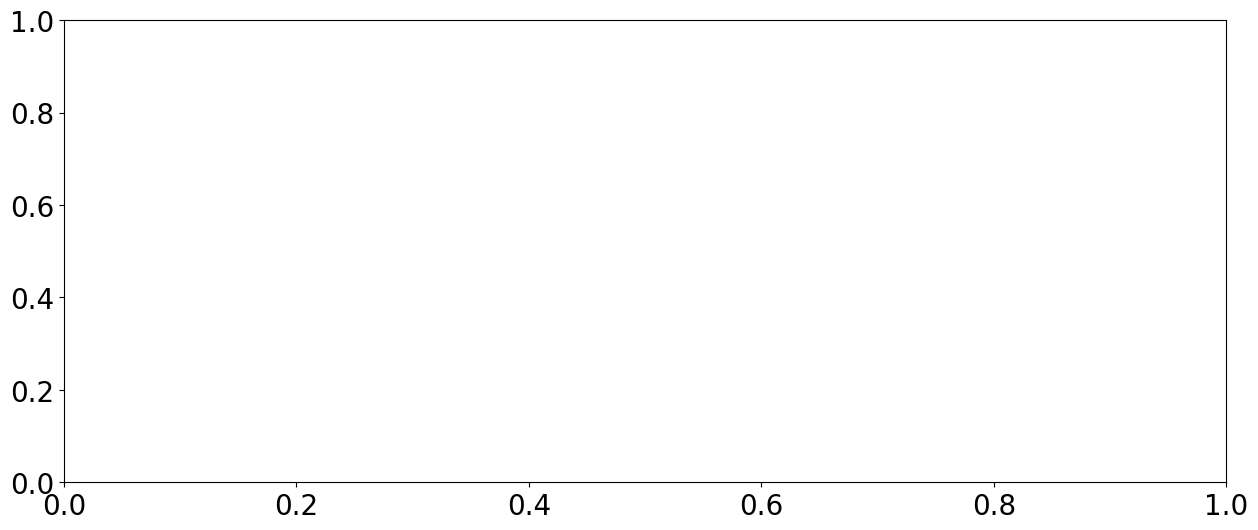

In [68]:
fig, ax = plt.subplots(figsize=(15, 6))

bar_width = 0.15
positions = np.arange(len(grouped))
for i in range(5):
    ax.bar(positions + i * bar_width, grouped[i], width=bar_width, label=f'{i}')

ax.set_xlabel('Driving durations (hours)')
ax.set_ylabel('% of total trip durations')

ax.set_xticks(positions + 2 * bar_width)
ax.set_xticklabels(grouped.index, rotation=45)
ax.legend(title='Occupancy level', bbox_to_anchor=(1, 1))

plt.savefig(f'{area}_occupancy_driving_duration.png', bbox_inches='tight')
# plt.show()

# Demand statistics

## Porto

In [72]:
from darpinstances.instance_generation.demand_to_database import load_data_from_csv
from darpinstances.instance_generation.convert_formats import RESOURCE_PATH
city = 'Porto'
csvfile = RESOURCE_PATH / f'{city}_trips.csv'
df = load_data_from_csv(csvfile)

KeyboardInterrupt: 

In [103]:
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['Year/Month'] = df['timestamp'].dt.to_period('M')
df['Day'] = df['timestamp'].dt.date

In [104]:
trips_per_month = df.groupby('Year/Month').size().reset_index(name='Trips Per Month')
trips_per_day = df.groupby(['Year/Month', 'Day']).size().reset_index(name='Trips Per Day')
days_per_month = trips_per_day.groupby('Year/Month').size().reset_index(name='Days Per Month')
merged_trips = pd.merge(trips_per_month, days_per_month, on='Year/Month')
merged_trips['Avg Trips Per Day'] = merged_trips['Trips Per Month'] / merged_trips['Days Per Month']

In [105]:
new_columns = ['Year/Month', 'Trips Per Month', 'Avg Trips Per Day']
stat_df = pd.DataFrame(columns=new_columns)
stat_df['Year/Month'] = merged_trips['Year/Month'].astype(str)
stat_df['Trips Per Month'] = merged_trips['Trips Per Month']
stat_df['Avg Trips Per Day'] = merged_trips['Avg Trips Per Day'].round()

In [106]:
year_month_np = stat_df['Year/Month'].to_numpy()
avg_trips_per_day_np = stat_df['Avg Trips Per Day'].to_numpy()
trips_per_month_np = stat_df['Trips Per Month'].to_numpy()

16:02:57 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
16:02:57 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


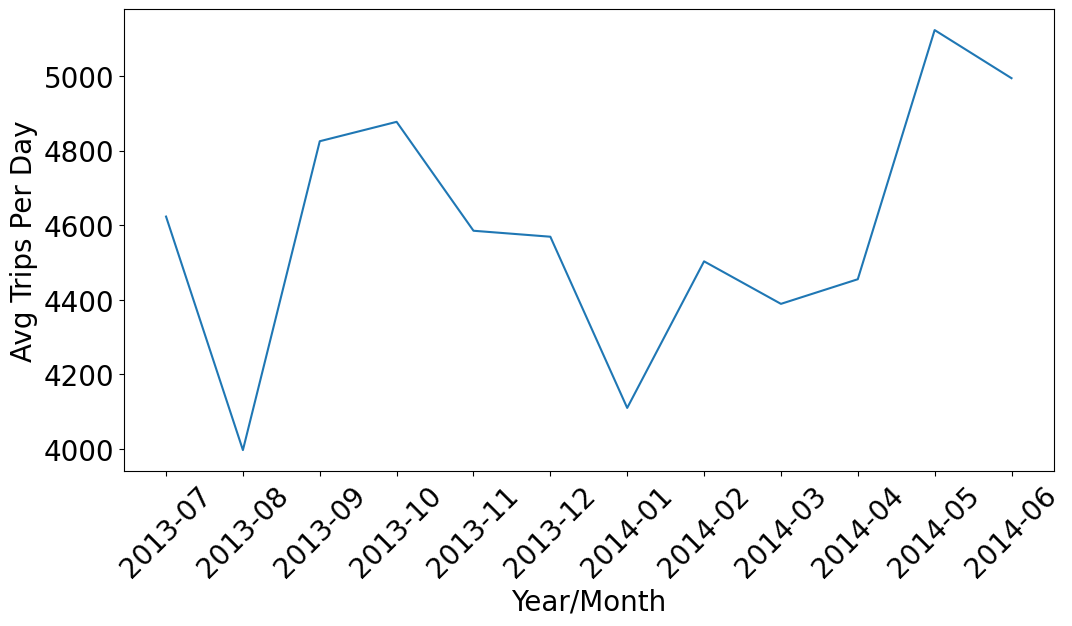

In [109]:
# Plot the average trips per day
plt.figure(figsize=(12, 6))
plt.plot(year_month_np, avg_trips_per_day_np)
plt.xlabel('Year/Month')
plt.ylabel('Avg Trips Per Day')
# plt.title('Average Trips Per Day Over Time')
plt.xticks(rotation=45)
plt.savefig(f'{city}_avg_trips_per_day.png', bbox_inches='tight')
plt.show()

16:03:08 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
16:03:08 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


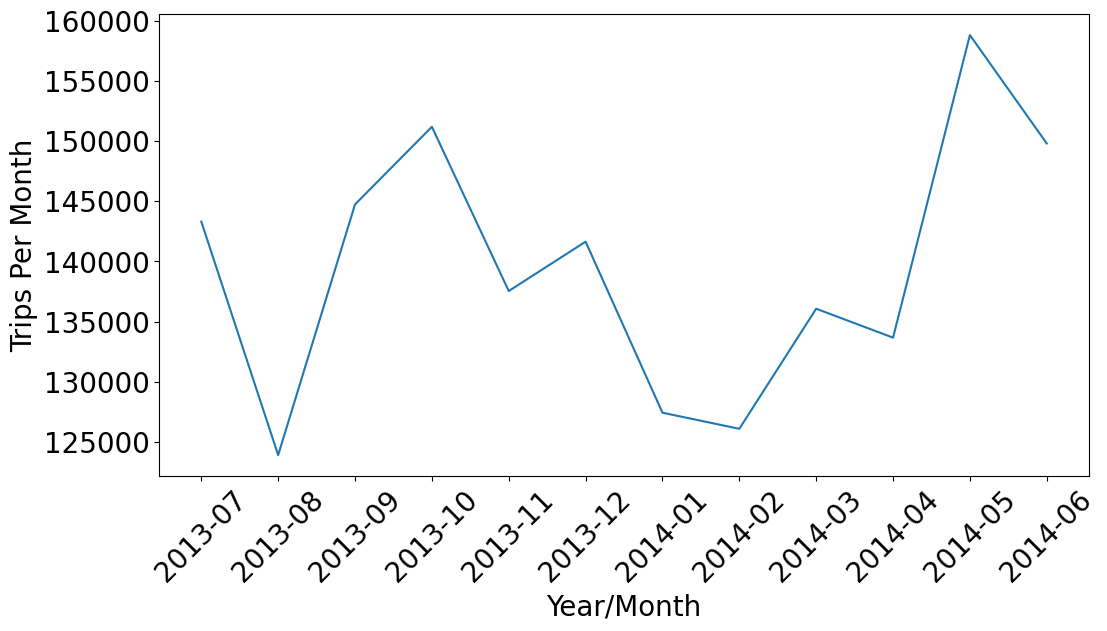

In [110]:
plt.figure(figsize=(12, 6))
plt.plot(year_month_np, trips_per_month_np)
plt.xlabel('Year/Month')
plt.ylabel('Trips Per Month')
# plt.title('Trips Per Month Over Time')
plt.xticks(rotation=45)
plt.savefig(f'{city}_trips_per_month.png', bbox_inches='tight')
plt.show()

### Daily stats

In [111]:
start_date = pd.to_datetime('2013-07-01')
end_date = pd.to_datetime('2013-07-07')
df_week = df[(df['timestamp'] >= start_date) & (df['timestamp'] <= end_date)]

In [112]:
df_week.loc[:, 'Date'] = df_week['timestamp'].dt.date
df_week.loc[:, 'Hour'] = df_week['timestamp'].dt.hour

trips_per_hour = df_week.groupby(['Date', 'Hour']).size().reset_index(name='Trips Per Hour')

trips_per_hour['Datetime'] = pd.to_datetime(trips_per_hour['Date'].astype(str) + ' ' + trips_per_hour['Hour'].astype(str) + ':00:00')

datetimes = trips_per_hour['Datetime'].values
trips_per_hour_values = trips_per_hour['Trips Per Hour'].values

/tmp/ipykernel_29002/3966745859.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/tmp/ipykernel_29002/3966745859.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



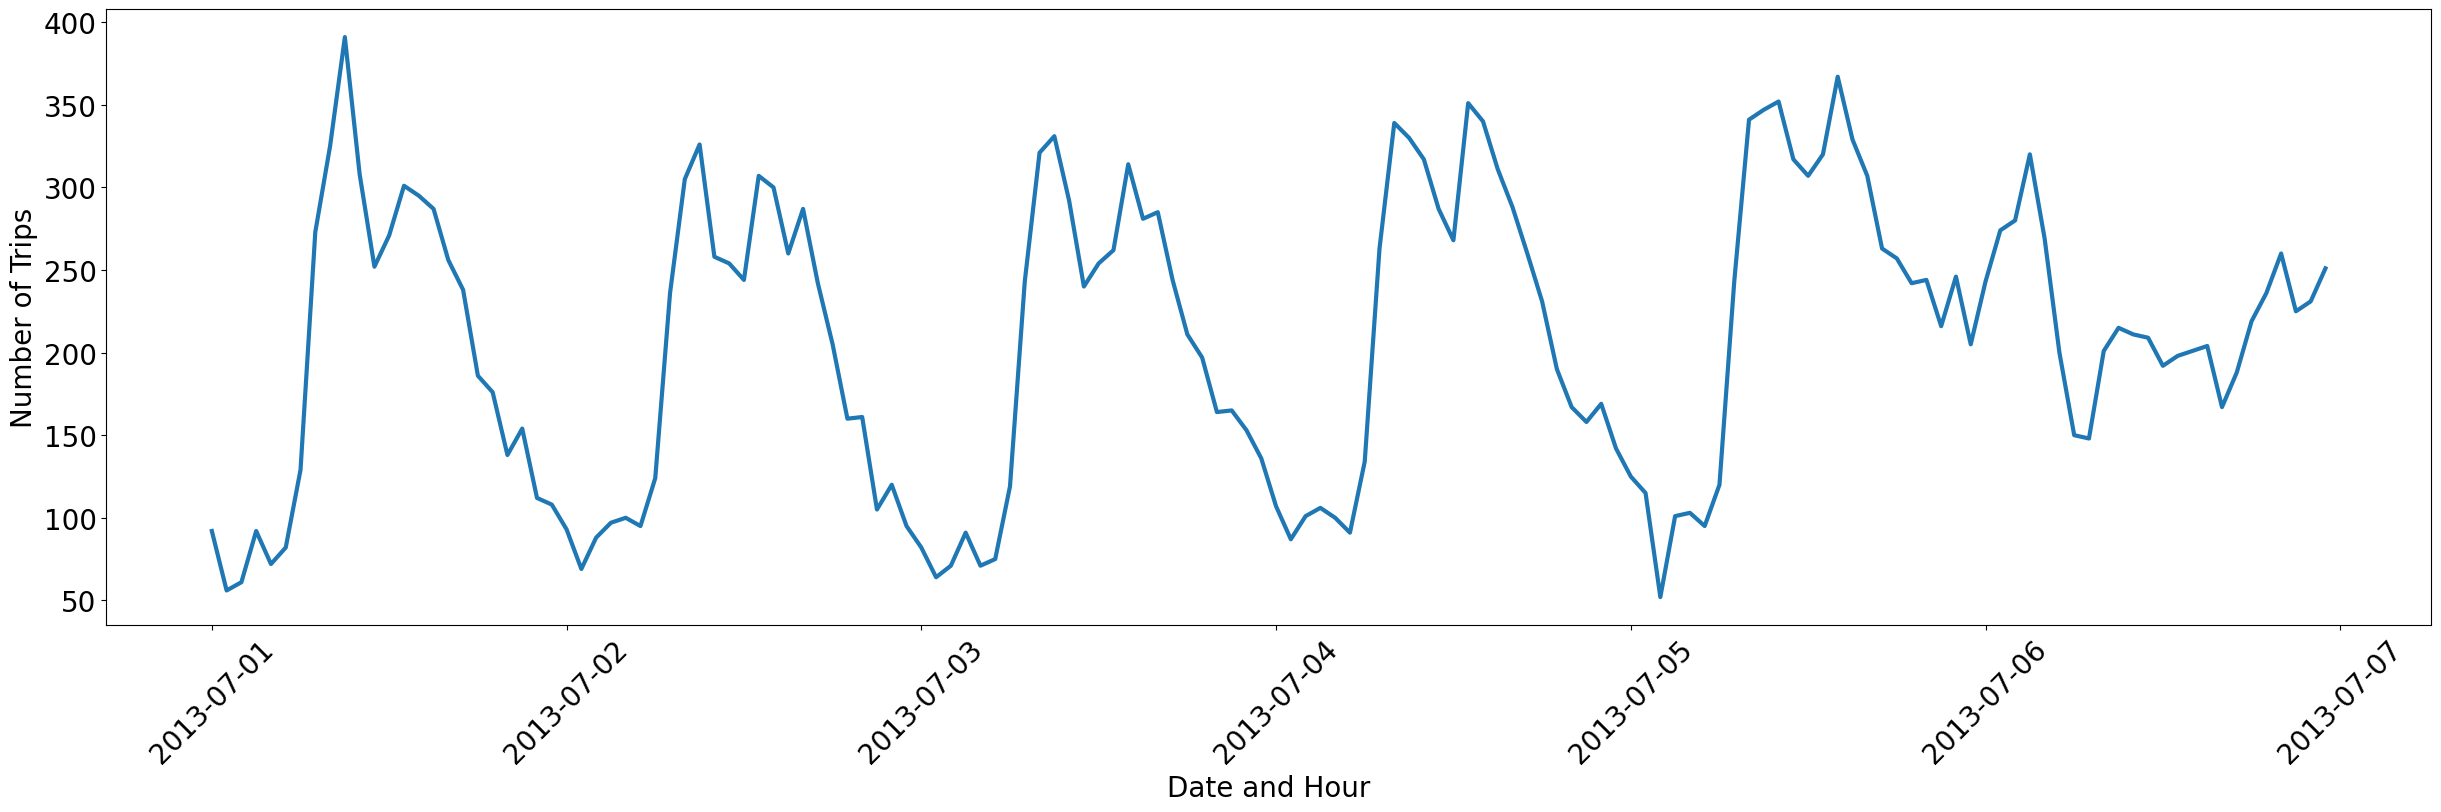

In [116]:
plt.figure(figsize=(30, 8))
plt.plot(datetimes, trips_per_hour_values, linewidth=3)
plt.xlabel('Date and Hour')
plt.ylabel('Number of Trips')
# plt.title('Number of Trips Per Hour from 2013-07-01 to 2013-07-07')
plt.xticks(rotation=45)
plt.savefig(f'{city}_trips_per_hour.png', bbox_inches='tight')
plt.show()

### 2013-07-01

In [117]:
df_oneday = df[df['timestamp'].dt.date == pd.to_datetime('2013-07-01').date()]

### hourly stats

In [118]:
df_oneday.loc[:, 'Hour'] = df_oneday['timestamp'].dt.hour
trips_per_hour = df_oneday.groupby('Hour').size().reset_index(name='Trips Per Hour')
hours = trips_per_hour['Hour'].to_numpy()
trips_per_hour_values = trips_per_hour['Trips Per Hour'].to_numpy()

/tmp/ipykernel_29002/3023397666.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



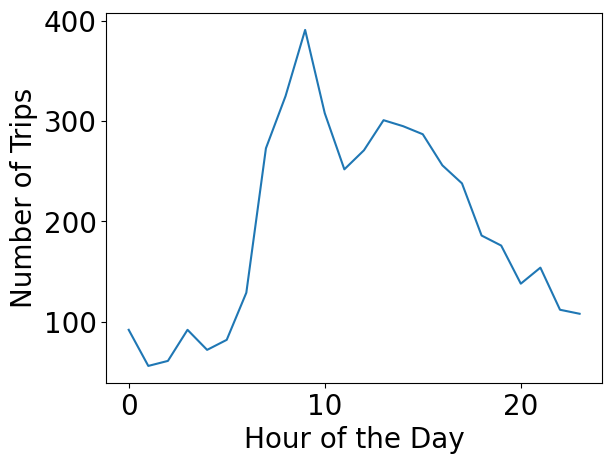

In [119]:
plt.plot(hours, trips_per_hour_values)
plt.xlabel('Hour of the Day')
plt.ylabel('Number of Trips')
# plt.title('Number of Trips Per Hour')
plt.savefig(f'{city}_trips_per_hour.png', bbox_inches='tight')
plt.show()

## Sydney

In [1]:
city = 'Sydney'

In [7]:
csvfile = RESOURCE_PATH / f'{city}_trips.csv'
df = load_data_from_csv(csvfile)

In [8]:
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['Year/Month'] = df['timestamp'].dt.to_period('M')
df['Day'] = df['timestamp'].dt.date

### 2014-01-01

In [9]:
df_oneday = df[df['timestamp'].dt.date == pd.to_datetime('2014-01-01').date()]

### hourly stats

In [10]:
df_oneday.loc[:, 'Hour'] = df_oneday['timestamp'].dt.hour
trips_per_hour = df_oneday.groupby('Hour').size().reset_index(name='Trips Per Hour')
hours = trips_per_hour['Hour'].to_numpy()
trips_per_hour_values = trips_per_hour['Trips Per Hour'].to_numpy()

/tmp/ipykernel_4870/3023397666.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_oneday.loc[:, 'Hour'] = df_oneday['timestamp'].dt.hour


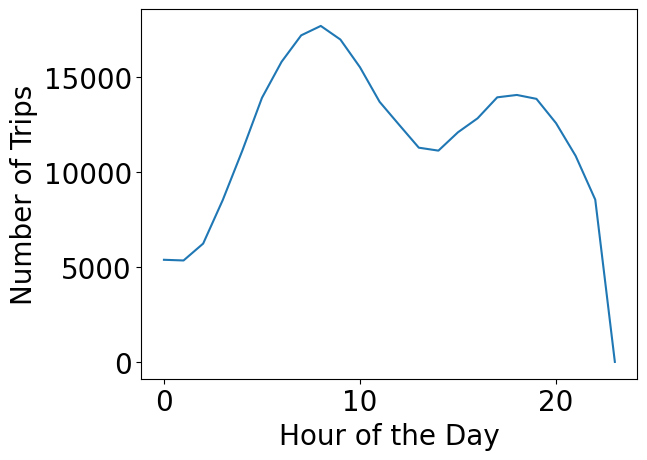

In [11]:
plt.plot(hours, trips_per_hour_values)
plt.xlabel('Hour of the Day')
plt.ylabel('Number of Trips')
plt.savefig(f'{city}_trips_per_hour.png', bbox_inches='tight')
plt.show()

# Methods performance

## Missing results of methods for areas

In [15]:
df_filtered = df[df['cost_per_request'] > 0][['max_delay', 'method', 'area_short', 'cost_per_request', 'duration_minutes']].drop_duplicates()

In [16]:
from itertools import product
# Generate all combinations of method, area_short, duration_minutes, and max_delay
methods = df_filtered['method'].unique()
areas = df_filtered['area_short'].unique()
durations = df_filtered['duration_minutes'].unique()
delays = df_filtered['max_delay'].unique()

all_combinations = pd.DataFrame(
    list(product(methods, areas, durations, delays)),
    columns=['method', 'area_short', 'duration_minutes', 'max_delay']
)

# Merge with the filtered data to find missing combinations
df_complete = all_combinations.merge(df_filtered, on=['method', 'area_short', 'duration_minutes', 'max_delay'], how='left')

# Add a column to mark missing values
df_complete['is_missing'] = df_complete['cost_per_request'].isna()

# Replace missing cost_per_request with 0 for plotting
df_complete['cost_per_request'] = df_complete['cost_per_request'].fillna(0)


In [17]:
method_order = sorted(df_complete['method'].unique())
method_offsets = {
    method: i - (len(method_order) - 1) / 2  # center around 0
    for i, method in enumerate(method_order)
}

# Mapping subplot (col, row) to axis index
vals_to_axis = {}
i = 1
delays = sorted(df_complete['max_delay'].unique(), reverse=True)
durations = sorted(df_complete['duration_minutes'].unique())
for max_delay in delays:
    for duration in durations:
        vals_to_axis[(duration, max_delay)] = i
        i += 1

In [23]:
fig = px.bar(
    df_complete,
    x='area_short',
    y='cost_per_request',
    color='method',
    barmode='group',
    title='Average cost per request by method and area',
    facet_col='duration_minutes',
    facet_row='max_delay'
)

# Drop duplicates for spacing reference
unique_areas = df_complete['area_short'].unique()

# Add X annotations for missing method/area combos
for _, row in df_complete[df_complete['is_missing']].iterrows():
    axis_ref = vals_to_axis[(row['duration_minutes'], row['max_delay'])]

    xref = f'x{axis_ref}' if axis_ref > 1 else 'x'
    yref = f'y{axis_ref}' if axis_ref > 1 else 'y'

    offset = method_offsets[row['method']] * 0.4  # tweak this for spacing
    fig.add_annotation(
        x=row['area_short'],
        y=0,
        text="X",
        xanchor='center',
        yanchor='bottom',
        showarrow=False,
        font=dict(color='black', size=14),
        xref=xref,
        yref=yref,
        xshift=offset * 50  # pixel offset for visual spacing
    )

# Shared axes titles
fig.for_each_yaxis(lambda y: y.update(title=''))  # Remove titles
fig.add_annotation(
    x=-0.06, y=0.5, text="Average cost per request [s]", textangle=-90,
    xref="paper", yref="paper", showarrow=False
)
fig.for_each_xaxis(lambda x: x.update(title=''))  # Remove titles
fig.add_annotation(
    x=0.5, y=1.15, text="Instance length [min]", xref="paper", yref="paper", showarrow=False
)  # Add shared title
fig.add_annotation(
    x=1.02, y=0.5, text="Maximum delay [s]", xref="paper", yref="paper", showarrow=False, textangle=90
)  # Add shared facet row title

fig.for_each_annotation(lambda a: a.update(text=a.text.split("=")[-1]))

fig.show()

### TODO: do the same for subsampling data

## Occupancy

In [40]:
oc_method = oc_df[['method', 'avg_occupancy', 'area_short', 'duration_minutes', 'max_delay']].drop_duplicates()

In [41]:
oc_method

,method,avg_occupancy,area_short,duration_minutes,max_delay
275,halns,0.763296,PT,5,180
286,ih,0.660198,PT,5,180
297,vga,0.845330,PT,5,180
264,vga_chaining,0.845330,PT,5,180
396,halns,0.880816,PT,5,300
...,...,...,...,...,...
2123,ih,1.945583,SY,30,900
2585,ih,1.057041,SY,120,180
2618,ih,1.266095,SY,120,300
2519,ih,1.675212,SY,120,600


In [31]:
fig = px.histogram(
    oc_df[oc_df['area_order'] == 0],
    # x='avg_delay',
    # y='avg_occupancy',
    y='avg_delay',
    x='avg_occupancy',
    barmode='group',
    color='method',
    title='Average Cost per Request by Area and Method',
)
fig.show()

In [214]:
avg_oc_df = oc_df.copy()
avg_oc_df['avg_delay_min'] = avg_oc_df['avg_delay'] / 60
avg_oc_df = avg_oc_df.sort_values(by=['area_short', 'method', 'avg_delay_min'])

### occupancy for area

In [215]:
codes = range(5)
area_code = codes[0]

In [216]:
area_avg_oc_df = avg_oc_df[avg_oc_df['area_order'] == area_code]

#### avg occupancy based on avg delay

In [26]:
fig = px.line(
    area_avg_oc_df,
    x='avg_delay_min',
    y='avg_occupancy',
    color='method',
    line_group='method',
    title=f'{area_code}: Average occupancy of each method based on average delay',
    labels={
        'avg_delay_min': 'Average Delay [min]',
        'avg_occupancy': 'Average Occupancy'
    }
)

fig.update_layout(
    height=600,
    width=1200,
    title_x=0.5
)

fig.for_each_annotation(lambda a: a.update(text=a.text.split("=")[-1]))  # Clean facet labels

fig.show()

NameError: name 'area_avg_oc_df' is not defined

#### occupancy based driving duration

In [217]:
area_avg_oc_df['total_driving_duration_minutes'] = area_avg_oc_df['total_driving_duration'] / 60
area_avg_oc_df['driving_duration_mins_per_vehicle'] = area_avg_oc_df['total_driving_duration_minutes']/area_avg_oc_df['plan_count']

/tmp/ipykernel_93761/3280263572.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/tmp/ipykernel_93761/3280263572.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [227]:
fig = px.histogram(
    area_avg_oc_df,
    x='occupancy',
    y='vehicle_hours',
    color='method',
    barmode='group',
    title=f'{area_code}: Occupancy of each method based on driving duration',
    labels={
        'occupancy': 'Occupancy',
        'vehicle_hours': 'Driving duration [h]'
    }
)
fig.show()

### speed of methods based on capacity (TODO)

In [27]:
fig = px.line(
    avg_oc_df[avg_oc_df['area_order'] ==0],
    x='occupancy',
    y='total_time',
    color='method',
    # barmode='group',
    title=f'Occupancy of each method based on driving duration',
    # labels={
    #     'occupancy': 'Occupancy',
    #     'vehicle_hours': 'Driving duration [h]',
    #     'area_short': 'Area'
    # },
    # facet_row='area_short',
    # facet_col='duration_minutes'
)

fig.for_each_yaxis(lambda y: y.update(title=''))  # Remove titles
fig.add_annotation(
    x=-0.06, y=0.5, text="Mean computational time [min]", textangle=-90,
    xref="paper", yref="paper", showarrow=False
)
fig.for_each_xaxis(lambda x: x.update(title=''))  # Remove titles
fig.add_annotation(
    x=0.5, y=1.15, text="Instance size [min]", xref="paper", yref="paper", showarrow=False
)  # Add shared title
fig.add_annotation(
    x=1.02, y=0.5, text="Areas", xref="paper", yref="paper", showarrow=False, textangle=90
)  # Add shared facet row title

fig.for_each_annotation(lambda a: a.update(text=a.text.split("=")[-1]))

fig.show()

NameError: name 'avg_oc_df' is not defined

### speed of methods based on vehicle count, requests count

In [291]:
df_filtered = oc_df[oc_df['cost_per_request'] > 0]

In [382]:
# sort_df = df_filtered.sort_values(by=['method', 'req_count'])
sort_df = df_filtered.sort_values(by=['method', 'total_time'])
sort_df['comp_time_min'] = sort_df['total_time'] / 60

In [391]:
fig = px.line(
    sort_df,
    x='comp_time_min',
    y='req_count',
    # y='comp_time_min',
    # x='req_count',
    color='method',
    title='Computational time vs. number of requests',
    text="req_count",
    # facet_col='area_short',
    facet_row='area_short',
)

# area_to_yaxis = {}
# for i, ann in enumerate(fig.layout.annotations):
#     area_name = ann.text.split('=')[-1]
#     yaxis_id = 'yaxis' if i == 0 else f'yaxis{i+1}'
#     area_to_yaxis[area_name] = yaxis_id
area_order = list(fig.layout.annotations[i].text.split('=')[-1] for i in range(len(fig.layout.annotations)))

for i, area_name in enumerate(area_order, start=1):
    req_data = sort_df[sort_df["area_short"] == area_name]  # Filter data for the current category
    bumper = 100
    if area_name == 'SY':
        bumper = 5000
    x_min = req_data["req_count"].min() - bumper
    x_max = req_data["req_count"].max() + bumper
    # x_min = req_data["comp_time_min"].min() -1
    # x_max = req_data["comp_time_min"].max() +1
    # fig.update_xaxes(range=[x_min, x_max], col=i, matches=None, row=1)
    fig.update_yaxes(range=[x_min, x_max], row=i, col=1, matches=None)
    # fig.layout[yaxis_id].update(range=[x_min, x_max])

fig.for_each_annotation(lambda a: a.update(text=a.text.split("=")[-1]))

fig.show()

In [397]:
# sort_plan_df = df_filtered.sort_values(by=['method', 'req_count'])
sort_plan_df = df_filtered.sort_values(by=['method', 'plan_count'])

In [399]:
fig = px.line(
    sort_plan_df,
    # y='plan_count',
    # x='req_count',
    x='plan_count',
    y='req_count',
    color='method',
    title='Computational time vs. number of requests',
    text="req_count",
    # facet_col='area_short',
    facet_row='area_short',
)

area_order = list(fig.layout.annotations[i].text.split('=')[-1] for i in range(len(fig.layout.annotations)))

for i, area_name in enumerate(area_order, start=1):
    req_data = sort_df[sort_df["area_short"] == area_name]  # Filter data for the current category
    bumper = 1
    if area_name == 'SY':
        bumper = 500
    x_min = req_data["req_count"].min() - bumper
    x_max = req_data["req_count"].max() + bumper
    # x_min = req_data["plan_count"].min() - bumper
    # x_max = req_data["plan_count"].max() + bumper
    # fig.update_xaxes(range=[x_min, x_max], col=i, matches=None, row=1)
    fig.update_yaxes(range=[x_min, x_max], row=i, col=1, matches=None)
    

fig.for_each_annotation(lambda a: a.update(text=a.text.split("=")[-1]))

fig.show()